# Checking if our graph is connected 

In [17]:
# only works if our txt is sorted by the first column
# which if it isn't then sorting it will fix it (tho that's another problem) but THIS specific data set seems to be sorted. Yay.

connected_subgarphs = [[0]] # First member added by hand
with open('Gowalla_edges.txt') as file:
    for line in file:

        line = line.rstrip()
        pair = tuple(map(int, line.split()))  # Read each line as a tuple st of couple numbers

        subgraph_pos = 0 
        for subgraph_i in connected_subgarphs:

            if (pair[0] in subgraph_i) and (pair[1]  in subgraph_i): # If both are in no need to do any
                break

            if (pair[0] in subgraph_i) and (pair[1] not in subgraph_i): # add node to subgraph as it is reachable
                subgraph_i.append(pair[1])
                break

            if (pair[1] in subgraph_i) and (pair[0] not in subgraph_i): # add node to subgraph as it is reachable
                subgraph_i.append(pair[0])
                break
        
            subgraph_pos += 1

        if subgraph_pos+1 > len(connected_subgarphs):      # Only case if both nodes are not in any of the subgraphs thus not reachable 
            connected_subgarphs.append([pair[0], pair[1]]) # Make a new subgaph


print(len(connected_subgarphs))

1


So not so interestingly we see that we do have a fully connected graph. Further graph exploration will be attempted later.

## Clustring DBscan for MAIN hubs

The main part of this clustering is to find out what points fall under the same large "activity hub". The motivation for this is the following assumption: having a chosen hub activities in another hub do grant extra info (ignoring friendships graphs). Later on it will be interesting to see if clustering into large hubs by chance is similalr to grouping people to "dense communities". Lastly as a consequence of grouping things into large hubs we will be able to find outliers (noise) and also see how large the hubs are.

The motivation for choosing DBscan is:
1) We do not need to choose cluster number a priori  (DBscan works)
2) Can handle differnece in distributions to some degree (Here DBscan might fail)

In [1]:
import pandas as pd
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('Gowalla_totalCheckins.txt', sep='\t', header=None, names=['user', 'check-in time', 'latitude', 'longitude', 'location_id'])
df.head()

,user,check-in time,latitude,longitude,location_id
0,0,2010-10-19T23:55:27Z,30.235909,-97.795140,22847
1,0,2010-10-18T22:17:43Z,30.269103,-97.749395,420315
2,0,2010-10-17T23:42:03Z,30.255731,-97.763386,316637
3,0,2010-10-17T19:26:05Z,30.263418,-97.757597,16516
4,0,2010-10-16T18:50:42Z,30.274292,-97.740523,5535878


In [4]:
original_len =len(df)
print(original_len, "number of entries")

6442892 number of entries


As seen from the map (ADRIAN) there as some coordinates that don't make sense. Thus we need to remove those that go out of latitude and longitude bounds

In [5]:
# Remove out of bound coordinates
df= df[(abs(df["longitude"]) <= 180) & (abs(df["latitude"]) <= 90)]
print(original_len - len(df), "points removed")

29 points removed


Now we still end up with a lot of data points (More than I can handle). We will split the world into two - Left (Americas) and right (Everything else) and this is valid under our assumption. The first guess as where to split is longitude = -30 which hould be around the middle of the atlantic ocean. This needs to be verified i.e. are we not accidentally splitting a potential cluster into two. (Most likely not as it is unlikely that a lot of things would happen in the middle of the ocean + Greenland but just to be safe we should keep this in mind.)

Before we split and merge by ID a good idea is to check if:
- all the points of the same ID are roughly in the same place (TODO)
- same id is not being used in another place.

Luckly the second thing is equivalent to checking if our original data frame has the the same number of unique ID as the left and right side unique ID sum.

In [8]:
# Split the world into 2
df_left  = df[df["longitude"] < -30]  
df_right = df[df["longitude"] >= -30] 

print(len(df_left), "on the left")
print(len(df_right), "on the right")

3816660 on the left
2626203 on the right


In [9]:
# Merge same locations
df_left_unique_id = df_left.drop_duplicates(subset=["location_id"])
df_right_unique_id = df_right.drop_duplicates(subset=["location_id"])
 
print(len(df_left_unique_id), " on the left")
print(len(df_right_unique_id), " on the right")

# And we know that we should get the same as num of unique ID before the split 
print(len(df.drop_duplicates(subset=["location_id"])) - len(df_right_unique_id) - len(df_left_unique_id), " the differnece between origina and splits num of unique ID")

712101  on the left
568855  on the right
0  the differnece between origina and splits num of unique ID


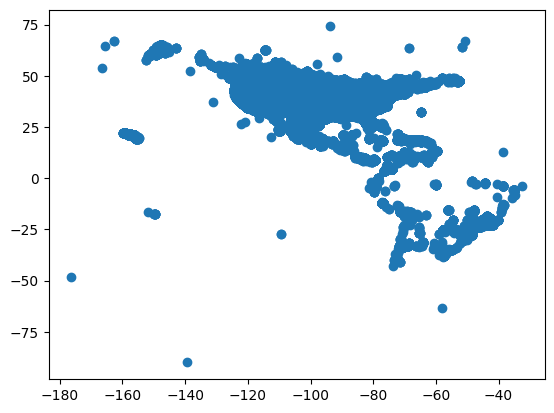

In [10]:
plt.scatter(df_left_unique_id["longitude"], df_left_unique_id["latitude"], )

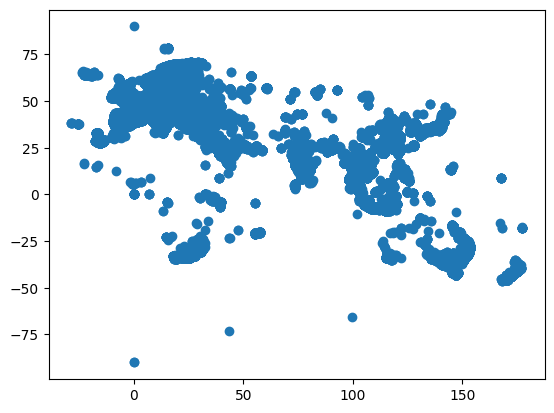

In [11]:
plt.scatter(df_right_unique_id["longitude"], df_right_unique_id["latitude"], )

# GOAL: BIG hub clustering

Now the two main problem are 1) what epsilon to choose, 2) handeling the amount of points. 

The min_samples for core point is chose to be quite low - first trial with 5 as we still want towns to belong to a hub and not be labled noise.

We know that one degree change is approximately (decreaes the further from equator we go) 111km change in distance. Yet this only gives a rough understanding on how to pick epsilon. As here we are trying to find the main BIG hubs we should not go too small i.e. picking small epsilon will produce more clusters (smaller hubs). Yet if we pick larger eps, for example even eps = 2, we face a memory problem as we have a lot of dense areas (for each neighborhood we have to check a large amount of points). A proposed solution for this is as follows:

1. Cut up the space into overlapping regions (based on coordinates)
2. Run DBSCAN for each region
3. If we have a cluster in the border region it gives us a connection how to act if they extent passed the border regions i.e. shows that it is the same cluster.

- TODO talk about why we need the overlap. Does overlap need certain size?

https://codesignal.com/learn/courses/density-based-clustering-simplified/lessons/exploring-dbscan-clustering-with-python-and-scikit-learn
https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/

# Left world clustering 

In [12]:
subset_num = 200000

In [17]:
DBSCAN_clustering = DBSCAN(eps=2, min_samples=5, metric="euclidean").fit(df_left_unique_id[["latitude", "longitude"]][0:subset_num])
# I found somewhere that  metric='haversine' is made for our type of coordiantes. Interesting to see what we'll get with this and euclidean.

# We get this amount of clusters - noise
print(len(set(DBSCAN_clustering.labels_)) - (1 if -1 in DBSCAN_clustering.labels_ else 0), "clusters not incl noise")
print(np.sum(DBSCAN_clustering.labels_ == -1), "points of noise")
print((np.sum(DBSCAN_clustering.labels_ == -1)/subset_num*100).round(2), "% of data is noise")

25 clusters not incl noise
42 points of noise
0.02 % of data is noise


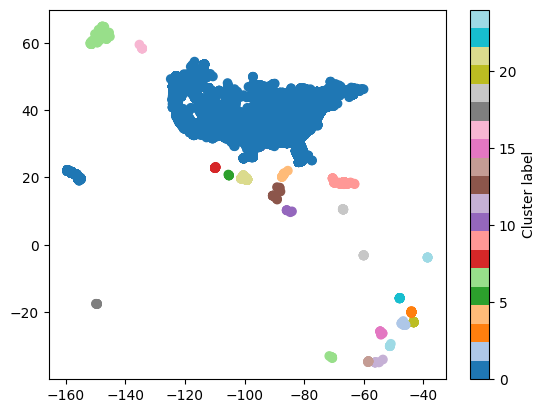

In [18]:
# Plot of NOT noise clusters
scatter = plt.scatter(df_left_unique_id['longitude'][0:subset_num][DBSCAN_clustering.labels_ != -1], 
                      df_left_unique_id['latitude'][0:subset_num][DBSCAN_clustering.labels_ != -1], 
                      c=DBSCAN_clustering.labels_[DBSCAN_clustering.labels_ != -1], cmap='tab20')

plt.colorbar(scatter, label='Cluster label')

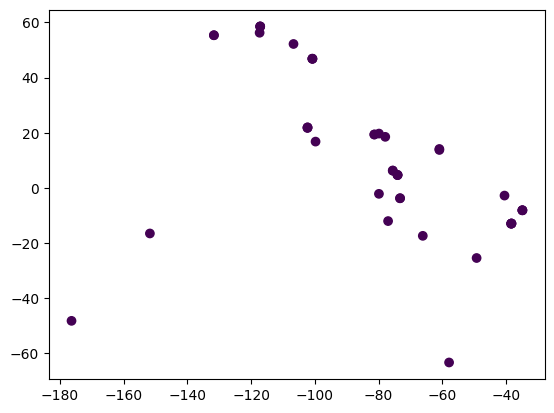

In [19]:
# Plotting noise:
lable_choice = -1  # label you want to plot

plt.scatter(
    df_left_unique_id['longitude'][0:subset_num][DBSCAN_clustering.labels_ == lable_choice],
    df_left_unique_id['latitude'][0:subset_num][DBSCAN_clustering.labels_ == lable_choice],
    c=DBSCAN_clustering.labels_[DBSCAN_clustering.labels_ == lable_choice]
)


# Right world clustering (Need to finish but prolly same stuff)